# Taller S2 · CONECTA S.A., Grupo \# 1

**Curso:** Visualización de Datos y Gerencia de la Información (UNAULA)

**Integrantes:** Maria Camila Grajales Perez, Stiware Alexander Quintero Aguirre, Juan Pablo Ramirez Gomez

**Grupo:** 1 v0.1_s2_dataviz_grupo1.ipynb

## Propósito

Experimentar con distintos tipos de gráfico para la misma pregunta y comparar cuál comunica mejor, en vez de aplicar una sola técnica por variable. La meta no es llegar rápido a un gráfico final, es probar y descartar con criterio.

Cada actividad pide construir más de un gráfico para la misma pregunta. No hay una respuesta correcta única: lo que se evalúa es la comparación y la justificación de cuál prefieren y por qué.

## Cómo usar este notebook

1. Dupliquen este archivo y renómbrenlo con el número de su grupo (por ejemplo `v0.1_s2_dataviz_grupo3.ipynb`).
2. En la celda de configuración de abajo, cambien `GRUPO` por su número (1 a 5) para cargar el archivo correcto.
3. Completen cada actividad en las celdas marcadas con `# TODO`. Las celdas de conclusión siguen el patrón que ya conocen: bullets basados en los números y gráficos que obtuvieron, cerrando con la pregunta de "Para pensar".
4. **Entregable:** este mismo notebook, con la tabla de clasificación y las siete actividades resueltas.


## 0. Configuración


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import unicodedata
import importlib
from itertools import cycle
import geopandas as gpd
import joypy
import squarify
import scipy.stats as st

# Parche de compatibilidad: joypy 0.2.6 espera que flatten_axes() de pandas
# devuelva una lista indexable, pero en versiones recientes de pandas devuelve
# un generador. Sin esto, joypy.joyplot() falla con
# "TypeError: 'generator' object is not subscriptable".
# Usamos importlib porque joypy/__init__.py hace "from .joyplot import joyplot",
# lo que pisa el nombre "joyplot" del paquete con la función; "import joypy.joyplot"
# terminaría apuntando a esa función en vez de al submódulo.
_joyplot_internal = importlib.import_module("joypy.joyplot")
_flatten_original = _joyplot_internal._flatten
_joyplot_internal._flatten = lambda axes: list(_flatten_original(axes))

pd.set_option("display.float_format", lambda x: f"{x:.2f}")

GRUPO = 1  # cambien este número por el de su grupo (1 a 5)

df = pd.read_csv(f"conecta_sa_grupo{GRUPO}.csv")
df.head()

def normalizar_texto(valor):
    if pd.isna(valor):
        return valor
    valor = str(valor).strip().lower()
    valor = ''.join(
        c for c in unicodedata.normalize('NFD', valor)
        if unicodedata.category(c) != 'Mn'
    )
    return valor
df["region"] = df["region"].apply(normalizar_texto)

### Una función que van a necesitar varias veces

`region` y `plan_type` traen variantes de escritura (mayúsculas, tildes faltantes, espacios extra). ¿Cómo lo solucionarían? A continuación, una propuesta:


In [2]:
def normalizar_texto(valor):
    texto = str(valor).strip().upper()
    for con_tilde, sin_tilde in [
        ("Á", "A"),
        ("É", "E"),
        ("Í", "I"),
        ("Ó", "O"),
        ("Ú", "U"),
    ]:
        texto = texto.replace(con_tilde, sin_tilde)
    return texto.title()


df["region_n"] = df["region"].apply(normalizar_texto)
df["tier_n"] = df["tier_localidad"].apply(normalizar_texto)
df[["region", "region_n", "tier_localidad", "tier_n"]].head()

,region,region_n,tier_localidad,tier_n
0,caribe,Caribe,Media,Media
1,andina,Andina,Baja,Baja
2,caribe,Caribe,Media,Media
3,andina,Andina,Media,Media
4,andina,Andina,Alta,Alta


## 1. Clasificación de columnas

**Propósito:** para cada columna del dataset de su grupo, completen la tabla: nombre de columna, tipo de dato (numérico continuo, categórico, temporal, geoespacial), y gráfico recomendado. Esta tabla guía las siguientes seis actividades, tómense el tiempo de hacerla bien antes de graficar nada.


In [3]:
df.dtypes

user_id                     str
mes                         str
pais                        str
region                      str
ciudad                      str
localidad                   str
tier_localidad              str
latitud                 float64
longitud                float64
plan_type                   str
signup_date                 str
tenure_months             int64
es_cliente_nuevo_mes       bool
monthly_revenue_cop     float64
data_usage_gb           float64
complaints_month          int64
nps_score               float64
churned                   int64
churn_type                  str
churn_date                  str
region_n                    str
tier_n                      str
dtype: object

Completen la columna de tipo de dato y gráfico recomendado:

| columna                | tipo de dato          | gráfico recomendado                       | Pregunta que puedes responder                                            |
| ---------------------- | --------------------- | ----------------------------------------- | ------------------------------------------------------------------------ |
| `user_id`              | texto - no aplica     | Lineas con mes                            | Cantidad de usuarios por mes                                             |
| `mes`                  | fecha-discreto        | Lineas con Churn                          | Evolución mensual del churn                                              |
| `pais`                 | texto-categorico      | Heatmap con región                        | ¿Cómo se distribuyen las regiones dentro del país?                       |
| `region`               | texto-categorico      | Barras apiladas con Churn                 | ¿Qué región tiene mayor proporción de churn?                             |
| `ciudad`               | texto-categorico      | top 10 con churn                          | ¿Qué ciudades presentan mayor proporción de abandono?                    |
| `localidad`            | texto-categorico      | treemap con tier_localidad                | Tamaño de cada localidad agrupada según su tier                          |
| `tier_localidad`       | cualitativo           | treemap con localidad                     | Tamaño de cada localidad agrupada según su tier                          |
| `latitud`              | geoespacial           | map con longitud + churned                | ¿En qué zonas se concentra el abandono?                                  |
| `longitud`             | geoespacial           | heat map con latitud + churn              | ¿Existen zonas donde se concentra más el churn?                          |
| `plan_type`            | cualitativo-sin orden | Pie con user_id                           | ¿Cómo se distribuyen los usuarios entre los diferentes tipos de plan     |
| `signup_date`          | fecha-continuo        | Lineas con nps_score                      | ¿La satisfacción cambia según el período en que ingresaron los clientes? |
| `tenure_months`        | numerico - discreto   | bubble char monthly_revenue_cop + churned | Relacionar antigüedad, ingresos y churn                                  |
| `es_cliente_nuevo_mes` | cualitativo           | Violin plot con data_usage_gb             | ¿El consumo de clientes nuevos es diferente al de los demás?             |
| `monthly_revenue_cop`  | numerico- discreto    | box plot con es_cliente_nuevo_mes         | ¿Los clientes nuevos pagan montos diferentes a los clientes antiguos?    |
| `data_usage_gb`        | numerico -continuo    | Violin plot con tier_localidad            | ¿Cómo cambia el consumo según el tier de localidad?                      |
| `complaints_month`     | numerico-discreto     | box plot con plan_type                    | ¿Cómo varía la cantidad de quejas según el tipo de plan?                 |
| `nps_score`            | Numerico-continuo     | Box plot con churn                        | ¿Los clientes que abandonaron tenían niveles de satisfacción diferentes? |
| `churned`              | cualitativo           | donut con tier_localidad                  | ¿Cómo cambia la proporción de churn según el tier?                       |
| `churn_type`           | texto-categorico      | heat map con plan_type                    | ¿Existen tipos de plan asociados con determinados tipos de churn?        |
| `churn_date`           | fecha-continuo        | Linea con user_id                         | ¿En qué fechas se concentraron más abandonos?                            |

**Para pensar:** ¿hay alguna columna que podrían clasificar de más de una forma según la pregunta que le hagan? ¿Cuál, y cuáles serían esas dos preguntas distintas?

En el dataset hay varias columnas que se pueden clasificar de diferentes formas según el objetivo.
Por ejemplo, monthly_revenue_cop y data_usage_gb son variables numéricas continuas o cuantitativas cuando se analizan sus valores exactos, pero si las agrupamos en rangos ya pueden ser categóricas.

Además, signup_date o churn_date pueden son variables temporales, pero se pueden agrupar en categorías como meses, trimestres o períodos para realizar comparaciones.


## 2. Cantidades, de tres formas

**Propósito:** respondan “¿cómo se distribuyen los usuarios entre las 5 regiones?” con tres gráficos distintos: barras verticales, un gráfico de puntos (dot plot), y un heatmap cruzando `region` con `tier_localidad`.

Este dataset es un panel: un mismo usuario puede aparecer en varias filas (un mes por fila). Para contar “usuarios” sin inflar el número, tomen un usuario por fila antes de agrupar, por ejemplo quedándose con la fila más reciente de cada `user_id`.


<Axes: title={'center': 'Grafica 1: Usuarios unicos por región'}, xlabel='region_n'>

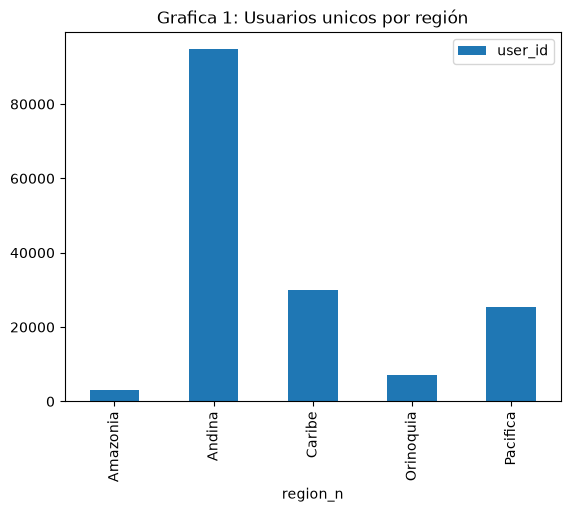

In [4]:
# Gráfico 1: barras verticales, usuarios únicos por región
# TODO: agrupen por region_n, cuenten usuarios únicos, grafiquen con plt.bar
# Verifiquen que el eje y incluya el cero

df[["user_id", "region_n"]].drop_duplicates().groupby("region_n").count().plot(
    kind="bar", title="Grafica 1: Usuarios unicos por región"
)

<Axes: title={'center': 'Grafico 2: Usuarios unicos por region (dot plot)'}, xlabel='region_n'>

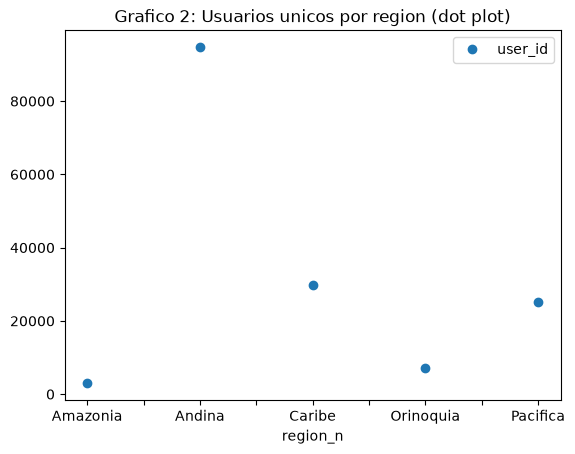

In [5]:
# Gráfico 2: dot plot, la misma cuenta pero como puntos
# TODO: mismos datos que el gráfico 1, con plt.scatter o plt.plot(marker="o", linestyle="none")

df[["user_id", "region_n"]].drop_duplicates().groupby("region_n").count().plot(
    marker="o",
    linestyle="none",
    title="Grafico 2: Usuarios unicos por region (dot plot)",
)

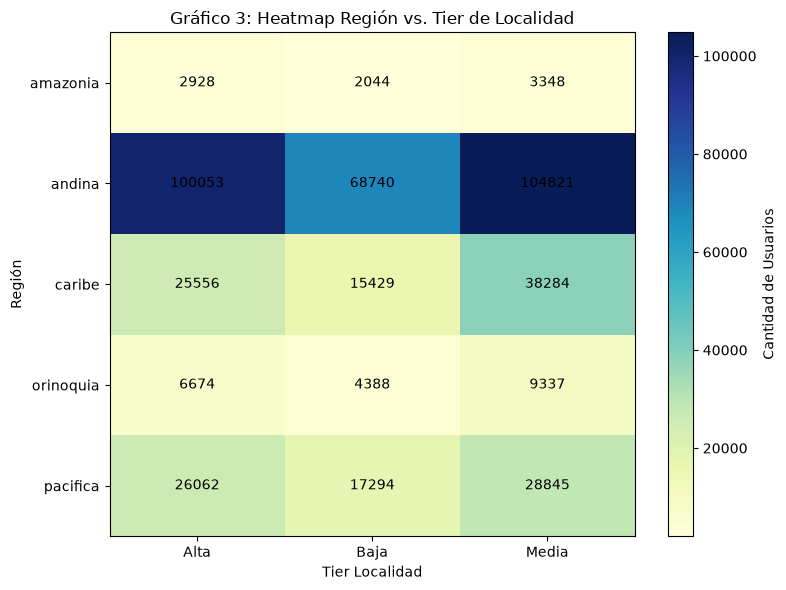

In [6]:
# Gráfico 3: heatmap region x tier_localidad
# TODO: tabla cruzada con pd.crosstab(df["region_n"], df["tier_n"]), graficada con plt.imshow
crosstab_df = pd.crosstab(df["region"], df["tier_localidad"])
 
# 3. Configurar y graficar con plt.imshow
plt.figure(figsize=(8, 6))
cax = plt.imshow(crosstab_df, cmap='YlGnBu', aspect='auto')
 
# Añadir barra de color
plt.colorbar(cax, label='Cantidad de Usuarios')
 
# 4. Configurar los ejes (es indispensable en imshow para que no salgan números del 0 al n)
plt.xticks(np.arange(len(crosstab_df.columns)), crosstab_df.columns)
plt.yticks(np.arange(len(crosstab_df.index)), crosstab_df.index)
 
# 5. Agregar el texto dentro de cada celda del heatmap
for i in range(len(crosstab_df.index)):
    for j in range(len(crosstab_df.columns)):
        plt.text(j, i, crosstab_df.iloc[i, j], ha="center", va="center", color="black")
 
# 6. Etiquetas finales
plt.title('Gráfico 3: Heatmap Región vs. Tier de Localidad')
plt.xlabel('Tier Localidad')
plt.ylabel('Región')
plt.tight_layout()
 
plt.show()


**Conclusión**:
La región Andina concentra la mayor cantidad de usuarios, con una gran diferencia respecto a las demás regiones donde la Amazonía presentan una menor cantidad de usuarios.
Las gráficas de barras y el dot plot permiten identificar estas diferencias y comparar la cantidad de usuarios entre regiones.

**Para pensar**:
Para un dashboard gerencial, empleariamos la gráfica de barras, porque permite identificar de forma rápida y clara qué regiones tienen la mayor y menor cantidad de usuarios. El dot plot también podría utilizarse, aunque las barras facilitan más la comparación visual de magnitudes.

El heatmap sería más apropiado para un dashboard técnico, cuando se use para analizar dos dimensiones o variables simultáneamente. En este caso específico, al representar únicamente usuarios por región, no aporta tanta claridad como las otras dos gráficas porque no permite interpretar fácilmente la distribución de usuarios por región, ya que pierde las etiquetas y el significado directo de las categorías


## 3. Asociaciones, de dos formas

**Propósito:** En la sesión construimos un scatter de `complaints_month` contra `data_usage_gb` (la relación que vimos en la teoría) la idea es buscar otras dos variables para buscar su relación y, por separado, un correlograma con todas las variables numéricas del dataset.


<Axes: title={'center': 'Grafico 4: Complaints vs nps_score'}, xlabel='nps_score', ylabel='complaints_month'>

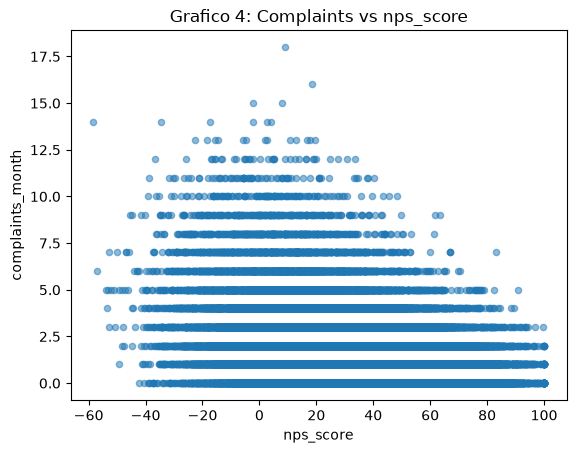

In [7]:
# Gráfico 1: scatter variable1 vs variable2
# TODO: plt.scatter(df["variable1"], df["variable2"], alpha=...)
# opción 1
df[["complaints_month", "nps_score"]].plot(
    kind="scatter", y="complaints_month", x="nps_score", alpha=0.5, title="Grafico 4: Complaints vs nps_score"
)

# opción 2
# df[['complaints_month','tenure_months']].plot(kind='scatter',y='complaints_month',x='tenure_months')


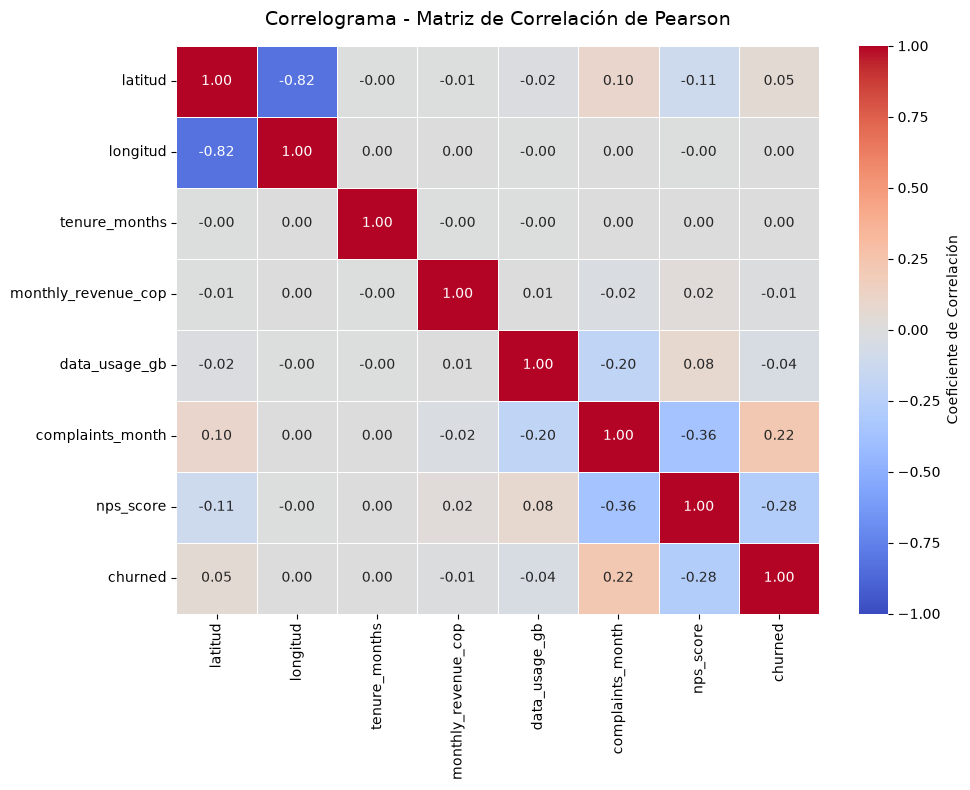

In [8]:
# Gráfico 2: correlograma de las variables numéricas
# TODO: calculen df[columnas_numericas].corr() y grafiquen, por ejemplo con sns.heatmap(annot=True)


df_num = df.select_dtypes(include=[np.number])


plt.figure(figsize=(10, 8))
# Calculamos la matriz de correlación
corr = df_num.corr()

# Mapa de calor (heatmap)
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    cbar_kws={"label": "Coeficiente de Correlación"},
)
plt.title(
    "Correlograma - Matriz de Correlación de Pearson",
    fontsize=14,
    pad=15,
)
plt.tight_layout()
plt.show()


**Conclusión:**
El análisis conjunto del scatter y el correlograma muestra que no existe una relación significativa entre el número de quejas mensuales y otras variables como el ingreso mensual del cliente, ya que la correlación es prácticamente nula. Sin embargo, sí se identifican relaciones importantes relacionadas con la satisfacción y el abandono: a mayor número de quejas, tiende a disminuir el nps_score, y los clientes con menor nivel de satisfacción presentan una mayor tendencia al churned. Además, se observa una relación negativa débil entre el consumo de datos y las quejas mensuales, lo que indica que los usuarios con mayor consumo tienden ligeramente a registrar menos quejas. Por otra parte, aunque la relación más fuerte de la matriz se presenta entre latitud y longitud, esta corresponde principalmente a la distribución geográfica de los registros y no representa una relación relevante para el negocio.

**Para pensar:**
El correlograma confirma lo que se vio en el scatter: no hay relación entre cuántas veces se queja un cliente y cuánto paga. La lectura visual (nube de puntos sin forma) coincide con el número (r cercano a cero).

Lo que llamó la atención y no se había explorado en el scatter es la cadena `complaints_month` → `nps_score` → `churned`: más quejas se asocian con menor satisfacción, y menor satisfacción con mayor abandono. Es una relación indirecta entre tres variables que solo aparece al mirar la matriz completa, no comparando pares sueltos.

## 4. El tiempo, de dos formas

**Propósito:** construyan una línea de evolución mensual (usuarios activos o tasa de churn, marzo a mayo) y, por separado, un slope graph que compare solo marzo contra mayo por región.

La columna `mes` es texto (por ejemplo `"2026-03"`). Ordenarla como texto ya funciona porque el formato es año-mes, pero si prefieren fechas reales pueden convertirla con `pd.to_datetime`.


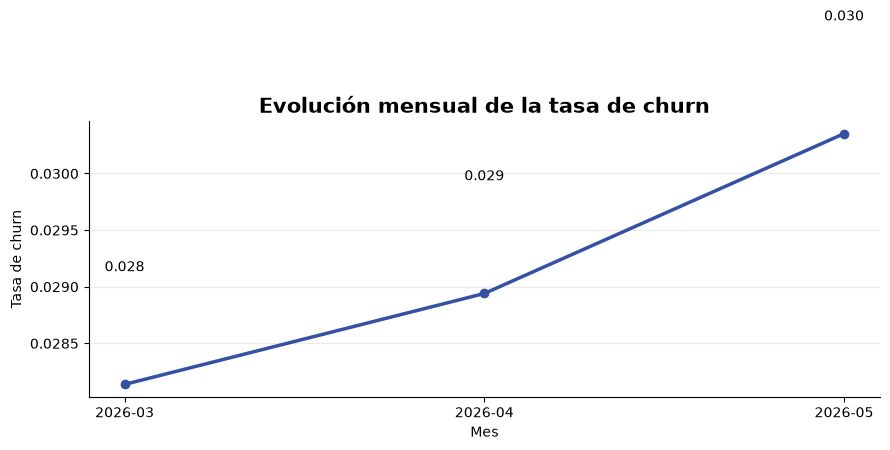

In [9]:
# Gráfico 1: línea de evolución mensual (usuarios activos o tasa de churn)
# TODO: agrupen por mes, calculen la métrica elegida, grafiquen con plt.plot

evolucion_mensual_churn = (
    df.groupby("mes")
      .agg(
          tasa_churn=("churned", "mean")
      )
      .reset_index()
)

ig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    evolucion_mensual_churn["mes"],
    evolucion_mensual_churn["tasa_churn"],
    marker="o",
    linewidth=2.5,
    color="#3451A3"
)

# Mostrar valores
for x, y in zip(
    evolucion_mensual_churn["mes"],
    evolucion_mensual_churn["tasa_churn"]
):
    ax.text(
        x,
        y + 0.001,
        f"{y:.3f}",
        ha="center",
        fontsize=10
    )

ax.set_title(
    "Evolución mensual de la tasa de churn",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel("Mes")
ax.set_ylabel("Tasa de churn")

ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

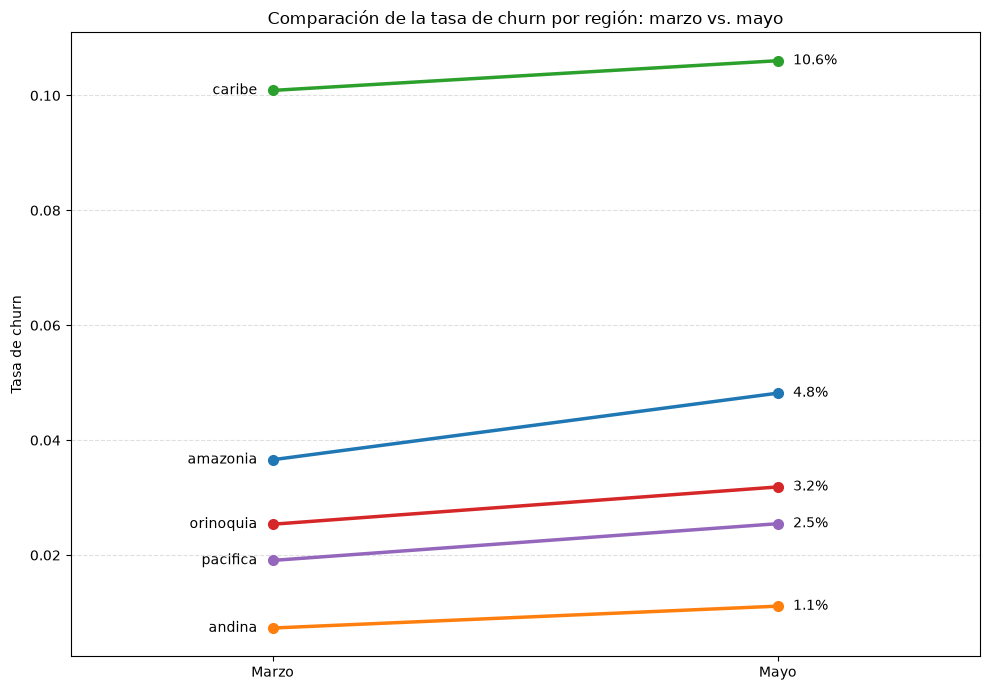

In [10]:

# Gráfico 2: slope graph, marzo vs. mayo, por región
# TODO: para cada región, un punto en marzo y otro en mayo, unidos por una línea
# (dos posiciones fijas en el eje x, plt.plot([0, 1], [valor_marzo, valor_mayo]) por cada región)

# Pivotar los datos: regiones en filas y meses en columnas
# Crear una posición para las etiquetas


# ============================================================
# GRÁFICO 2: SLOPE GRAPH - MARZO VS. MAYO POR REGIÓN
# Métrica: tasa de churn
# ============================================================

# 1. Filtrar únicamente marzo y mayo
df_slope = df[df["mes"].isin(["2026-03", "2026-05"])].copy()

# 2. Calcular la tasa de churn por región y mes
# Se asume que churned contiene 1 si el usuario hizo churn y 0 si no
tasa_churn = (
    df_slope
    .groupby(["region", "mes"])["churned"]
    .mean()
    .reset_index()
)

# 3. Pivotar los datos:
# Regiones en filas y meses en columnas
slope_data = tasa_churn.pivot(
    index="region",
    columns="mes",
    values="churned"
)

# 4. Crear una lista de colores
lista_colores = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b"
]

# 5. Asignar un color a cada región
colores_region = {
    region: color
    for region, color in zip(
        slope_data.index,
        cycle(lista_colores)
    )
}

# 6. Ordenar las regiones según la tasa de churn de mayo
regiones_ordenadas = slope_data.sort_values("2026-05")

# 7. Crear la figura
fig, ax = plt.subplots(figsize=(10, 7))

# 8. Para cada región, un punto en marzo y otro en mayo,
# unidos por una línea
for region, fila in regiones_ordenadas.iterrows():

    valor_marzo = fila["2026-03"]
    valor_mayo = fila["2026-05"]

    color = colores_region[region]

    ax.plot(
        [0, 1],
        [valor_marzo, valor_mayo],
        marker="o",
        markersize=7,
        linewidth=2.5,
        color=color
    )

    # Etiqueta de la región a la izquierda
    ax.text(
        -0.03,
        valor_marzo,
        region,
        ha="right",
        va="center"
    )

    # Etiqueta con el valor de mayo a la derecha
    ax.text(
        1.03,
        valor_mayo,
        f"{valor_mayo:.1%}",
        ha="left",
        va="center"
    )

# 9. Configurar el eje X
ax.set_xticks([0, 1])
ax.set_xticklabels(["Marzo", "Mayo"])

# 10. Configurar el gráfico
ax.set_title("Comparación de la tasa de churn por región: marzo vs. mayo")
ax.set_ylabel("Tasa de churn")

ax.set_xlim(-0.4, 1.4)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

**Conclusión:** 
- *Evolución mensual de la tasa de churn:*La tasa de churn presenta una tendencia creciente entre marzo y mayo, pasando aproximadamente de 2.8% en marzo a 3.0% en mayo.
- *Comparación de la tasa de churn por región: marzo vs. mayo:* En esta gráfica podemos visualizar un aumento progresivo entre marzo y mayo en todas las regiones analizadas. Siendo Caribe la más alta  Andina la más baja.

**Para pensar:** ¿cuál comunica mejor una tendencia sostenida? ¿Cuál comunica mejor un cambio puntual entre dos momentos?
 La gráfica de línea de evolución mensual comunica mejor una tendencia sostenida, porque permite observar cómo cambia la tasa de churn a lo largo del tiempo y seguir su evolución mes a mes. 

 El slope graph comunica mejor un cambio puntual entre dos momentos, porque permite comparar directamente el valor inicial y final de cada región y observar cuáles aumentaron o disminuyeron más.

## 5. Geoespacial, de dos formas

**Propósito:** construyan un mapa de puntos coloreado por alguna métrica (`churned`, `complaints_month`, o `monthly_revenue_cop`) y, por separado, un choropleth agregado por región para la misma métrica.

Las coordenadas traen algunos valores problemáticos: nulos, o fuera del rango de Colombia (latitud aproximadamente entre -4 y 13, longitud entre -79 y -66). Filtren esos casos antes del mapa de puntos, no hace falta corregirlos, alcanza con dejarlos por fuera para esta actividad.

Para el choropleth necesitan un polígono por región, no solo puntos. El archivo `data/geo/colombia_departamentos.geo.json` trae los 33 departamentos de Colombia; en la sesión ya vieron cómo agruparlos en las 5 regiones de CONECTA con un diccionario departamento → región y `.dissolve(by="region")`. Reutilicen ese mismo patrón.


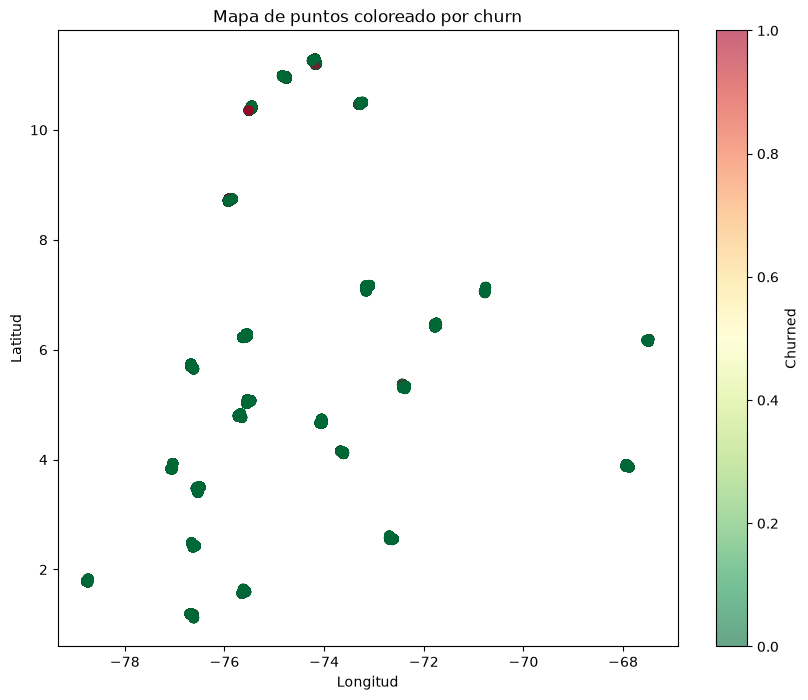

In [11]:


# Gráfico 1: mapa de puntos
# TODO: filtren coordenadas válidas y grafiquen plt.scatter(longitud, latitud, c=metrica, cmap=...)



# Gráfico 1: mapa de puntos

# Definir la métrica
metrica = "churned"

# Filtrar coordenadas válidas
df_mapa = df[
    df["latitud"].notna() &
    df["longitud"].notna() &
    df["latitud"].between(-4, 13) &
    df["longitud"].between(-79, -66)
].copy()

# Crear el gráfico
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    df_mapa["longitud"],
    df_mapa["latitud"],
    c=df_mapa[metrica],
    cmap="RdYlGn_r",
    alpha=0.6
)

# Barra de colores
plt.colorbar(scatter, label="Churned")

# Título y etiquetas
plt.title("Mapa de puntos coloreado por churn")
plt.xlabel("Longitud")
plt.ylabel("Latitud")

plt.show()

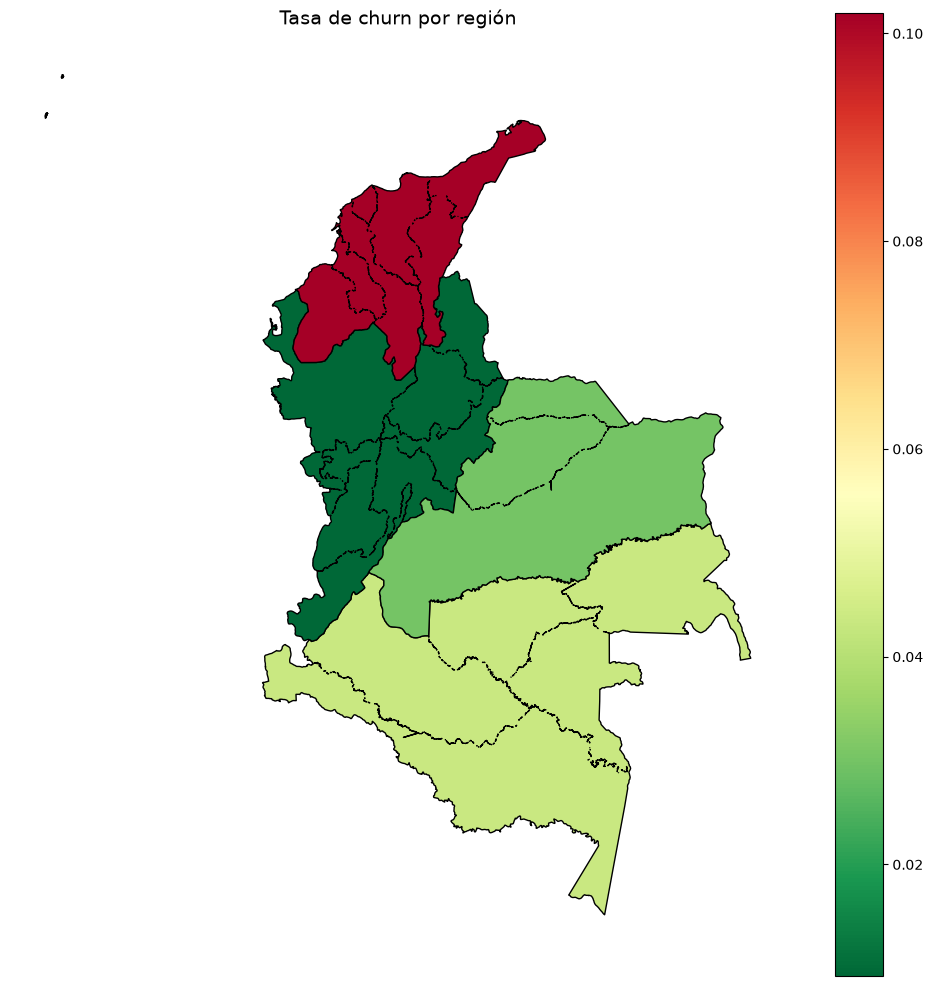

In [12]:

# Gráfico 2: choropleth por región
# TODO: carguen data/geo/colombia_departamentos.geo.json, agrupen los departamentos en las 5 regiones
# de CONECTA (mismo patrón visto en la sesión), agreguen su métrica por region_n y grafiquen con .plot(column=...)


# ============================================================
# Gráfico 2: choropleth por región
# ============================================================

# Usar la misma métrica del gráfico 1
metrica = "churned"

# 1. Cargar el archivo geográfico de departamentos
geo = gpd.read_file("colombia_departamentos.geo.json")

# 2. Diccionario departamento -> región CONECTA
# Claves normalizadas (mayúsculas, sin tildes) porque así viene NOMBRE_DPT en el GeoJSON
# (ej. "SANTAFE DE BOGOTA D.C", "NARIÑO"). No reutilizamos la función normalizar_texto
# del notebook porque más arriba fue redefinida (ahora deja tildes en la Ñ y usa Title Case).
departamento_region = {
    "AMAZONAS": "Amazonia",
    "ANTIOQUIA": "Andina",
    "ARAUCA": "Orinoquia",
    "ATLANTICO": "Caribe",
    "BOLIVAR": "Caribe",
    "BOYACA": "Andina",
    "CALDAS": "Andina",
    "CAQUETA": "Amazonia",
    "CASANARE": "Orinoquia",
    "CAUCA": "Pacifico",
    "CESAR": "Caribe",
    "CHOCO": "Pacifico",
    "CORDOBA": "Caribe",
    "CUNDINAMARCA": "Andina",
    "GUAINIA": "Amazonia",
    "GUAVIARE": "Amazonia",
    "HUILA": "Andina",
    "LA GUAJIRA": "Caribe",
    "MAGDALENA": "Caribe",
    "META": "Orinoquia",
    "NARINO": "Pacifico",
    "NORTE DE SANTANDER": "Andina",
    "PUTUMAYO": "Amazonia",
    "QUINDIO": "Andina",
    "RISARALDA": "Andina",
    "ARCHIPIELAGO DE SAN ANDRES PROVIDENCIA Y SANTA CATALINA": "Caribe",
    "SANTANDER": "Andina",
    "SUCRE": "Caribe",
    "TOLIMA": "Andina",
    "VALLE DEL CAUCA": "Pacifico",
    "VAUPES": "Amazonia",
    "VICHADA": "Orinoquia",
    "SANTAFE DE BOGOTA D.C": "Andina",
}

# 3. Asignar una región a cada departamento
# Normalizamos NOMBRE_DPT (mayúsculas + sin tildes) de forma local a esta celda,
# para no depender del estado cambiante de normalizar_texto en el resto del notebook
def _normalizar_departamento(valor):
    texto = str(valor).strip().upper()
    return ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

geo["NOMBRE_DPT_N"] = geo["NOMBRE_DPT"].apply(_normalizar_departamento)
geo["region"] = geo["NOMBRE_DPT_N"].map(departamento_region)

# 4. Agrupar los departamentos en las 5 regiones
geo_regiones = geo.dissolve(by="region").reset_index()

# 5. Calcular la tasa promedio de churn por región
metrica_region = (
    df.groupby("region_n")[metrica]
    .mean()
    .reset_index()
)

# 6. Unificar el nombre de la columna para hacer el merge
metrica_region = metrica_region.rename(
    columns={"region_n": "region"}
)

# 7. Unir los polígonos con la métrica calculada
geo_choropleth = geo_regiones.merge(
    metrica_region,
    on="region",
    how="left"
)

# 8. Crear el choropleth
fig, ax = plt.subplots(figsize=(10, 10))

geo_choropleth.plot(
    column=metrica,
    cmap="RdYlGn_r",
    legend=True,
    edgecolor="black",
    ax=ax
)

# 9. Configuración del gráfico
ax.set_title("Tasa de churn por región", fontsize=14)
ax.axis("off")

plt.tight_layout()
plt.show()

**Conclusión:** _(bullets aquí, basados en los números que obtuvieron arriba)_

**Para pensar:** ¿en qué punto el detalle del mapa de puntos deja de aportar y se vuelve ruido visual?


## 6. La trampa de `churn_type`

**Propósito:** construyan un gráfico de barras de `churn_type` tal cual viene la columna. Después, construyan una segunda versión que deje explícito qué fracción del total de usuarios representa cada barra, no solo de los que churnearon.


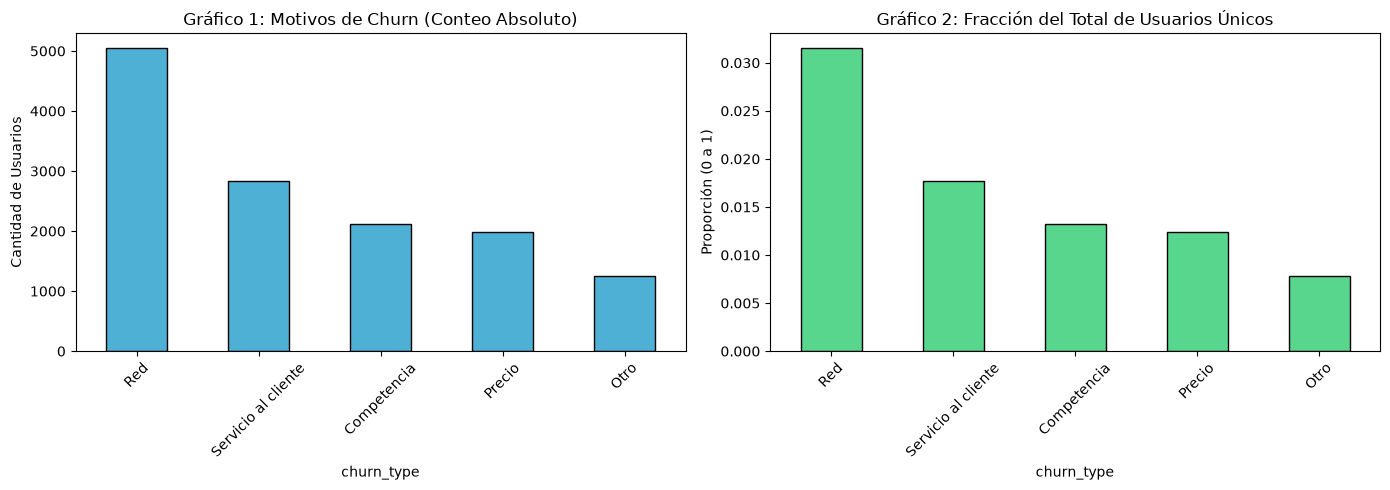

In [13]:
# Gráfico 1: barras de churn_type tal cual
# TODO: df["churn_type"].value_counts().plot(kind="bar") o equivalente en matplotlib puro

# Gráfico 2: la misma barra, como fracción del total de usuarios (no solo de los que churnearon)
# TODO: dividan cada conteo entre el total de usuarios únicos del dataset, no entre el total de churneados

# Configuración de la figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Gráfico 1: barras de churn_type tal cual (frecuencia absoluta)
df["churn_type"].value_counts().plot(
    kind="bar", 
    ax=axes[0], 
    color='#4EB0D4', 
    edgecolor='black'
)
axes[0].set_title("Gráfico 1: Motivos de Churn (Conteo Absoluto)")
axes[0].set_ylabel("Cantidad de Usuarios")
axes[0].tick_params(axis='x', rotation=45)
 
# Gráfico 2: fracción sobre el total de usuarios únicos
total_usuarios = df["user_id"].nunique()
(df["churn_type"].value_counts() / total_usuarios).plot(
    kind="bar", 
    ax=axes[1], 
    color='#58D68D', 
    edgecolor='black'
)
axes[1].set_title("Gráfico 2: Fracción del Total de Usuarios Únicos")
axes[1].set_ylabel("Proporción (0 a 1)")
axes[1].tick_params(axis='x', rotation=45)
 
plt.tight_layout()
plt.show()


**Conclusión:** _(bullets aquí, basados en los números que obtuvieron arriba)_

**Para pensar:** ¿la primera versión puede llevar a una lectura equivocada? ¿Por qué?


## 7. Repitiendo lo avanzado, con su propio dataset

**Propósito:** la sesión ya mostró ridgeline (joypy), treemap (squarify) y error bars sobre CONECTA en general. Repitan **al menos dos** de esas tres técnicas con el dataset de su propio grupo.

### 7a. Ridgeline (joypy)

Un ridgeline de `monthly_revenue_cop` o `data_usage_gb`, por `mes` o por `tier_localidad`.


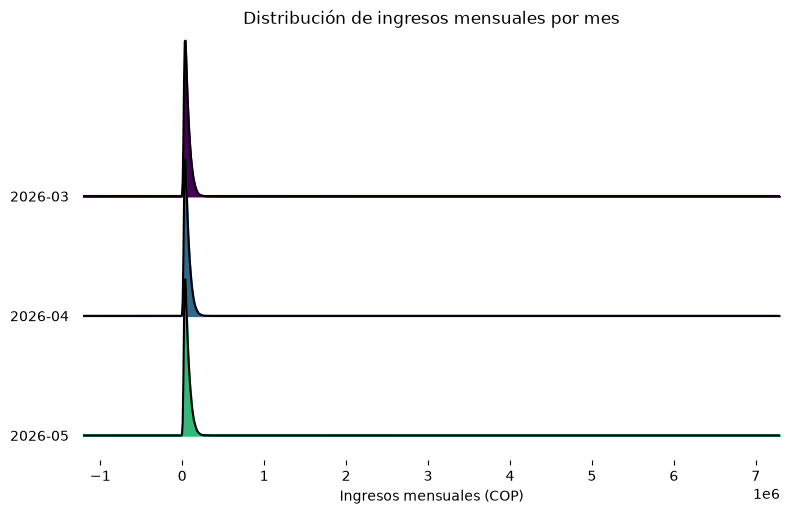

In [14]:


# TODO: joypy.joyplot(df, by=..., column=..., figsize=(8, 5), colormap=plt.cm.viridis)
# Revisen si necesitan recortar el eje (x_range) como en la demo, según qué tan larga
# sea la cola de valores altos en la columna que elijan



# Ridgeline: distribución de ingresos mensuales por mes

fig, axes = joypy.joyplot(
    df,
    by="mes",
    column="monthly_revenue_cop",
    figsize=(8, 5),
    colormap=plt.cm.viridis
)

plt.title("Distribución de ingresos mensuales por mes")
plt.xlabel("Ingresos mensuales (COP)")
plt.show()

### 7b. Treemap (squarify)

Un treemap propio de `region` x `tier_localidad`, con los datos de su grupo: la combinación crítica de su grupo es distinta a la de la demo.


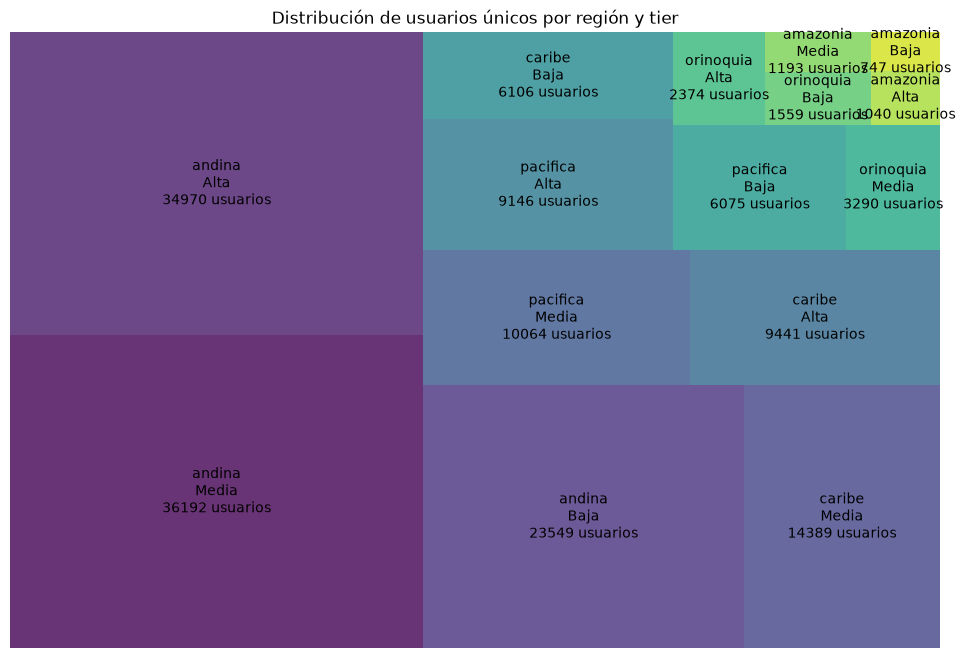

In [15]:


# TODO: agrupen por region_n y tier_n, cuenten usuarios únicos, ordenen de mayor a menor
# y grafiquen con squarify.plot(sizes=..., label=..., color=...)

# Agrupar por región y tier, contando usuarios únicos
treemap_data = (
    df.groupby(["region", "tier_localidad"])
    ["user_id"]
    .nunique()
    .reset_index(name="usuarios_unicos")
)
 
# Ordenar de mayor a menor
treemap_data = treemap_data.sort_values(
    by="usuarios_unicos",
    ascending=False
)
 
# Crear las etiquetas
labels = (
    treemap_data["region"].astype(str)
    + "\n"
    + treemap_data["tier_localidad"].astype(str)
    + "\n"
    + treemap_data["usuarios_unicos"].astype(str)
    + " usuarios"
)
 
# Crear el gráfico
plt.figure(figsize=(12, 8))

# Colores explícitos: si no se pasa color, squarify intenta usar
# matplotlib.cm.get_cmap(), que fue removido en versiones recientes de
# matplotlib y rompe con "'matplotlib.cm' has no attribute 'get_cmap'"
colores = [
    plt.cm.viridis(i / len(treemap_data))
    for i in range(len(treemap_data))
]

squarify.plot(
    sizes=treemap_data["usuarios_unicos"],
    label=labels,
    color=colores,
    alpha=0.8
)
 
# Título
plt.title("Distribución de usuarios únicos por región y tier")
 
# Quitar los ejes
plt.axis("off")
 
plt.show()

### 7c. Error bars (opcional, si prefieren esta a una de las dos anteriores)

Promedio de `monthly_revenue_cop` o `data_usage_gb` por región, con intervalo de confianza.


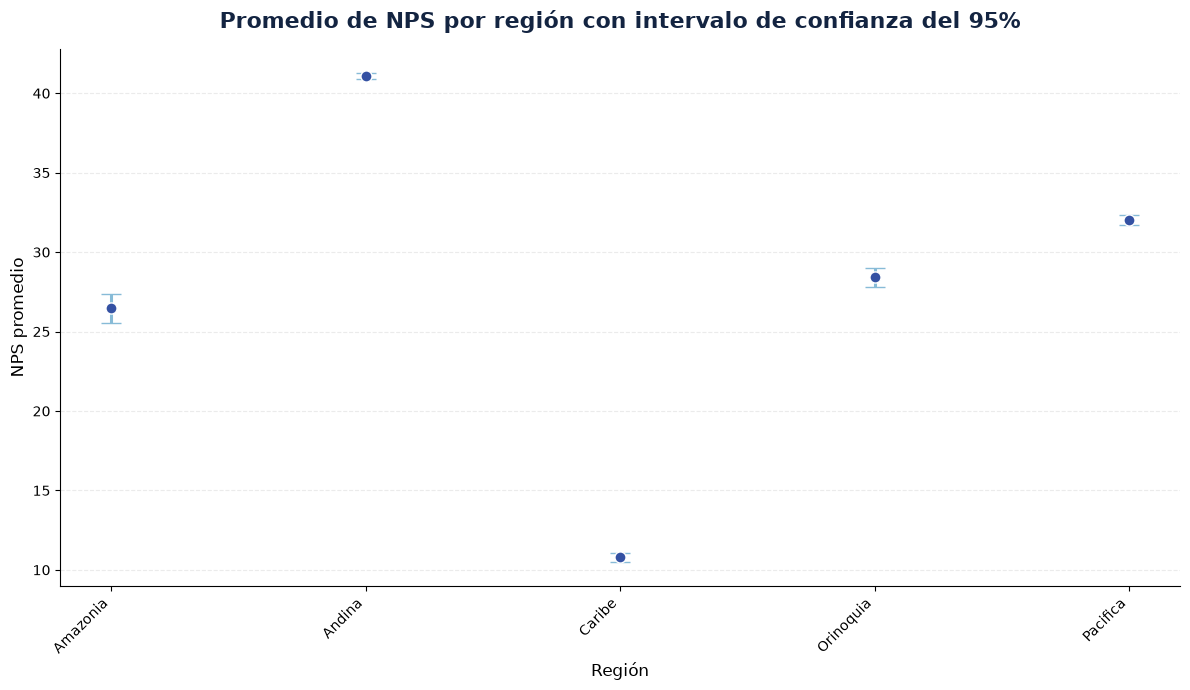

In [59]:
resumen_region = (
    df.groupby("region_n")["nps_score"]
      .agg(["mean", "std", "count"])
      .reset_index()
)
 
# Error estándar
resumen_region["error_estandar"] = (
    resumen_region["std"] / np.sqrt(resumen_region["count"])
)
 
# Intervalo de confianza del 95%
resumen_region["ic95"] = 1.96 * resumen_region["error_estandar"]
 
 
# Crear gráfica
fig, ax = plt.subplots(figsize=(12, 7))
 
ax.errorbar(
    resumen_region["region_n"],
    resumen_region["mean"],
    yerr=resumen_region["ic95"],
    fmt="o",
    markersize=8,       # Aumenta el tamaño de los puntos
    capsize=7,          # Aumenta las líneas horizontales
    capthick=2,         # Grosor de los extremos
    elinewidth=2.2,     # Grosor del intervalo
    color="#3451A3",    # Lapis Blue
    ecolor="#87BBD7",   # Powder Blue
    markerfacecolor="#3451A3",
    markeredgecolor="white",
    markeredgewidth=1
)
 
# Título y etiquetas
ax.set_title(
    "Promedio de NPS por región con intervalo de confianza del 95%",
    fontsize=16,
    fontweight="bold",
    color="#132441",
    pad=15
)
 
ax.set_xlabel("Región", fontsize=12)
ax.set_ylabel("NPS promedio", fontsize=12)
 
# Diseño minimalista
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
 
# Mejorar etiquetas
plt.xticks(rotation=45, ha="right")
 
plt.tight_layout()
plt.show()

**Conclusión:** _(bullets aquí, basados en los números y gráficos de las dos técnicas que eligieron)_

**Para pensar:** ¿alguna de las dos técnicas que eligieron les reveló algo que no habían visto en las gráficas más simples de las actividades anteriores? ¿Cuál, y qué fue?


## Entregable

Este mismo notebook (`v0.1_s2_dataviz_grupoN.ipynb`, con su número de grupo). Antes de entregar, revisen: ¿cada conclusión está basada en los números y gráficos que de verdad obtuvieron?
